# t-SNE

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

Q1. Load the data provided in the file 

In [5]:
# Update this path to point to your tsne.txt file
data = pd.read_table(r"C:\Users\admin\Downloads\Project 01 skeleton code\tsne (1).txt")
data
X = np.log1p(data.values)

## Q2. square distances

In [6]:
n = X.shape[0]
dist = euclidean_distances(X, X) ** 2

## Q3. probabilities and perplexity

In [7]:
def prob_high_dim(sigma, dist_row):
    """
    For each row of Euclidean distance matrix (dist_row) compute
    probability in high dimensions (1D array).
    pj|i = exp(-dij / 2sigma^2) / sum_{k!=i} exp(-dik / 2sigma^2)
    """
    num = np.exp(-dist_row / (2 * sigma**2))
    num[dist_row == 0] = 0   # exclude self (i==j)
    denom = np.sum(num)
    return num / (denom + 1e-10)

def perplexity(prob):
    """
    Compute perplexity (scalar) for each 1D array of high-dimensional probability.
    Perp(Pi) = 2^{H(Pi)}, where H(Pi) = -sum_j p_{j|i} log2 p_{j|i}
    """
    prob = prob[prob > 0]  # avoid log(0)
    H = -np.sum(prob * np.log2(prob))
    return 2 ** H

## Q4. binary search algorithm

In [8]:
def sigma_binary_search(perp_of_sigma, fixed_perplexity, tol=1e-5):
    """
    Solve equation perp_of_sigma(sigma) = fixed_perplexity
    with respect to sigma by the binary search algorithm.
    """
    low, high = 1e-10, 1000.0
    for _ in range(1000):
        mid = (low + high) / 2
        current = perp_of_sigma(mid)
        if abs(current - fixed_perplexity) < tol:
            return mid
        if current < fixed_perplexity:
            low = mid
        else:
            high = mid
    return mid

## Q5. find the value of sigma for perplexity = 30

In [9]:
PERPLEXITY = 30
sigmas = []
for i in range(n):
    perp_of_sigma = lambda s: perplexity(prob_high_dim(s, dist[i]))
    sigma_i = sigma_binary_search(perp_of_sigma, PERPLEXITY)
    sigmas.append(sigma_i)
sigma = np.mean(sigmas)

## Q6. calculate symmetric probabilities

In [10]:
# Symmetrise conditional probabilities: p_ij = (p_{j|i} + p_{i|j}) / 2n
P_cond = np.array([prob_high_dim(sigmas[i], dist[i]) for i in range(n)])
P = (P_cond + P_cond.T) / (2 * n)
P = np.maximum(P, 1e-12)

## Q7. calculate the probabilities in the target space

In [11]:
def prob_low_dim(Y):
    """
    Compute matrix of probabilities q_ij in low-dimensional space.
    Uses Student t-distribution with 1 degree of freedom (Cauchy kernel):
    q_ij = (1 + ||y_i - y_j||^2)^{-1} / sum_{k!=l} (1 + ||y_k - y_l||^2)^{-1}
    """
    sq_dist = euclidean_distances(Y, Y) ** 2
    num = 1 / (1 + sq_dist)
    np.fill_diagonal(num, 0)  # q_ii = 0
    Q = num / (np.sum(num) + 1e-10)
    return np.maximum(Q, 1e-12)

## Q8. KL divergence and gradient

In [12]:
def KL(P, Y):
    """
    Compute KL-divergence from matrix of high-dimensional probabilities
    and coordinates of low-dimensional embeddings.
    KL(P||Q) = sum_{i!=j} p_ij * log(p_ij / q_ij)
    """
    Q = prob_low_dim(Y)
    return np.sum(P * np.log(P / Q))

def KL_gradient(P, Y):
    """
    Compute gradient of KL-divergence.
    dC/dy_i = 4 * sum_j (p_ij - q_ij)(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1}
    """
    Q = prob_low_dim(Y)
    y_diff = np.expand_dims(Y, 1) - np.expand_dims(Y, 0)          # (n, n, 2)
    inv_dist = 1 / (1 + euclidean_distances(Y, Y) ** 2)            # (n, n)
    return 4 * np.sum(np.expand_dims(P - Q, 2) * y_diff * np.expand_dims(inv_dist, 2), axis=1)

## Q9. Gradient descent

Iteration 100/500, KL = 3.0752
Iteration 200/500, KL = 1.2392
Iteration 300/500, KL = 1.2095
Iteration 400/500, KL = 1.2000
Iteration 500/500, KL = 1.1956


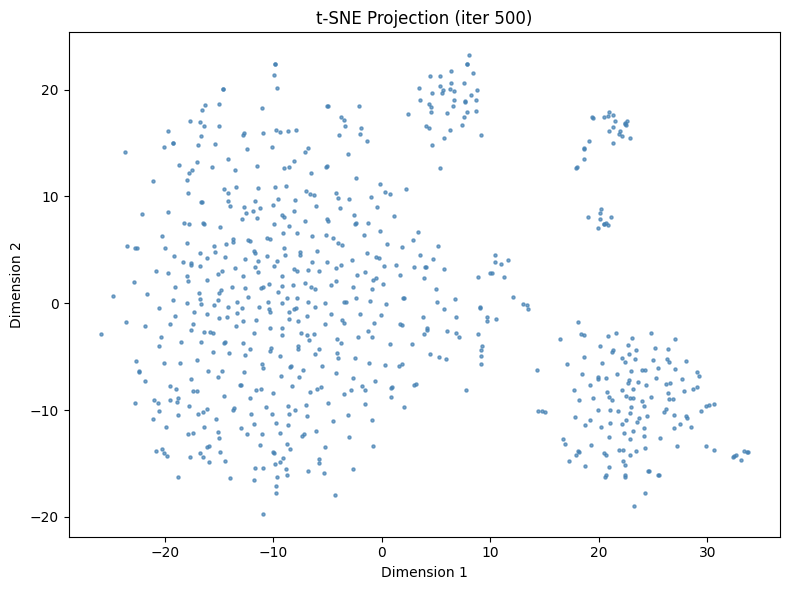

In [13]:
N_LOW_DIMS = 2
LEARNING_RATE = 200
MAX_ITER = 500
MOMENTUM = 0.9

np.random.seed(12345)
Y = np.random.normal(loc=0, scale=1e-4, size=(n, N_LOW_DIMS))
velocity = np.zeros_like(Y)

for t in range(MAX_ITER):
    # Early exaggeration: multiply P by 4 for first 100 iterations
    P_use = P * 4 if t < 100 else P
    grad = KL_gradient(P_use, Y)
    velocity = MOMENTUM * velocity - LEARNING_RATE * grad
    Y = Y + velocity
    # Centre the embedding
    Y -= Y.mean(axis=0)
    if (t + 1) % 100 == 0:
        print(f"Iteration {t+1}/{MAX_ITER}, KL = {KL(P, Y):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(Y[:, 0], Y[:, 1], s=5, c='steelblue', alpha=0.7)
plt.title('t-SNE Projection (iter 500)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()

---
# UMAP

## Q2. Fit piecewise function with non-linear least squares

Fitted parameters: a = 1.1214, b = 1.0575


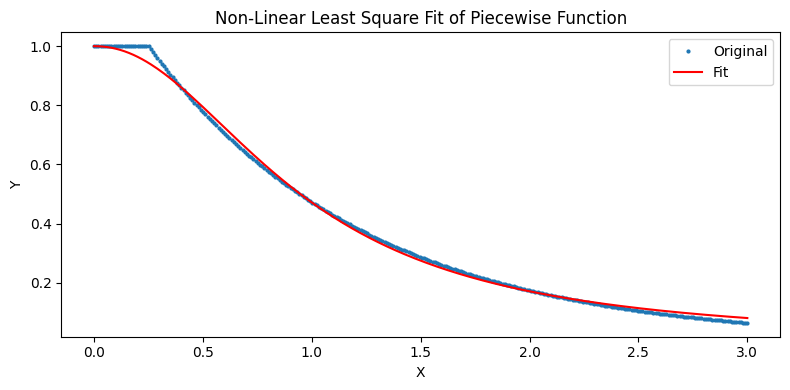

In [14]:
from scipy import optimize

MIN_DIST = 0.25   # typical UMAP default

x_fit = np.linspace(0, 3, 300)

def piecewise_f(x, min_dist):
    return np.where(x <= min_dist, 1.0, np.exp(-(x - min_dist)))

dist_low_dim = lambda x, a, b: 1 / (1 + a * x ** (2 * b))

p, _ = optimize.curve_fit(dist_low_dim, x_fit, piecewise_f(x_fit, MIN_DIST))
a_umap, b_umap = p
print(f'Fitted parameters: a = {a_umap:.4f}, b = {b_umap:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(x_fit, piecewise_f(x_fit, MIN_DIST), 'o', ms=2, label='Original')
plt.plot(x_fit, dist_low_dim(x_fit, a_umap, b_umap), c='red', label='Fit')
plt.title('Non-Linear Least Square Fit of Piecewise Function')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

## Q4. UMAP high-dimensional probabilities and binary search

In [16]:
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import euclidean_distances

# ---- Load data (update path as needed) ----
X = np.log1p(data.values)
n = X.shape[0]
dist_umap = euclidean_distances(X, X)   # NOT squared for UMAP

N_NEIGHBOR = 15

def prob_high_dim_umap(sigma, dist_row, rho):
    """
    UMAP high-dimensional similarity for row i.
    p_{j|i} = exp(-(d(i,j) - rho_i) / sigma_i)  for d > rho_i, else 1
    rho_i = distance to the nearest neighbour (ensures local connectivity)
    """
    d_shifted = np.maximum(dist_row - rho, 0.0)
    prob = np.exp(-d_shifted / (sigma + 1e-10))
    prob[dist_row == 0] = 0   # self excluded
    return prob

def k_umap(prob):
    """
    Effective number of neighbours = 2^{H} where H = -sum p log2(p).
    (Analogous to perplexity but for UMAP.)
    """
    prob = prob[prob > 0]
    H = -np.sum(prob * np.log2(prob + 1e-10))
    return 2 ** H

def sigma_binary_search_umap(k_of_sigma, fixed_k, tol=1e-5):
    """
    Solve k_of_sigma(sigma) = fixed_k via binary search.
    """
    low, high = 1e-10, 1000.0
    for _ in range(1000):
        mid = (low + high) / 2
        current = k_of_sigma(mid)
        if abs(current - fixed_k) < tol:
            return mid
        if current < fixed_k:
            low = mid
        else:
            high = mid
    return mid

## Q5. Build UMAP high-dimensional graph (P matrix)

In [17]:
MIN_DIST = 0.25

# Fit a and b for this min_dist
x_fit = np.linspace(0, 3, 300)
p_fit, _ = optimize.curve_fit(
    lambda x, a, b: 1 / (1 + a * x ** (2 * b)),
    x_fit, piecewise_f(x_fit, MIN_DIST)
)
a_umap, b_umap = p_fit
print(f'a = {a_umap:.4f}, b = {b_umap:.4f}')

# For each point find rho (distance to nearest neighbour)
rhos = []
for i in range(n):
    row = dist_umap[i].copy()
    row[i] = np.inf
    rhos.append(np.min(row))
rhos = np.array(rhos)

# Binary search for sigma_i such that effective k = N_NEIGHBOR
sigmas_umap = []
for i in range(n):
    k_of_sigma = lambda s: k_umap(prob_high_dim_umap(s, dist_umap[i], rhos[i]))
    sigmas_umap.append(sigma_binary_search_umap(k_of_sigma, N_NEIGHBOR))
sigmas_umap = np.array(sigmas_umap)

# Build conditional probability matrix
P_cond_umap = np.array([
    prob_high_dim_umap(sigmas_umap[i], dist_umap[i], rhos[i])
    for i in range(n)
])

# Symmetrise: p_ij = p_{j|i} + p_{i|j} - p_{j|i} * p_{i|j}  (UMAP union rule)
P_umap = P_cond_umap + P_cond_umap.T - P_cond_umap * P_cond_umap.T
P_umap = np.maximum(P_umap, 1e-12)

a = 1.1214, b = 1.0575


## Q6. Low-dimensional probabilities (UMAP cross-entropy and gradient)

In [18]:
def prob_low_dim_umap(Y, a, b):
    """
    UMAP low-dimensional similarity:
    q_ij = 1 / (1 + a * ||y_i - y_j||^{2b})
    """
    sq_dist = euclidean_distances(Y, Y) ** 2
    Q = 1 / (1 + a * sq_dist ** b)
    np.fill_diagonal(Q, 0)
    return np.clip(Q, 1e-12, 1 - 1e-12)

def CE_umap(P, Y, a, b):
    """
    UMAP cross-entropy loss:
    C = sum_{i,j} [ p_ij * log(p_ij/q_ij) + (1-p_ij)*log((1-p_ij)/(1-q_ij)) ]
    """
    Q = prob_low_dim_umap(Y, a, b)
    return -np.sum(P * np.log(Q + 1e-10) + (1 - P) * np.log(1 - Q + 1e-10))

def CE_gradient_umap(P, Y, a, b):
    """
    Gradient of UMAP cross-entropy w.r.t. Y.
    """
    sq_dist = euclidean_distances(Y, Y) ** 2
    Q = prob_low_dim_umap(Y, a, b)

    # dC/dq_ij
    dC_dQ = -P / (Q + 1e-10) + (1 - P) / (1 - Q + 1e-10)

    # dq_ij/d(||y_i-y_j||^2)
    denom = (1 + a * sq_dist ** b) ** 2
    dQ_ddist2 = -a * b * sq_dist ** (b - 1) / denom
    np.fill_diagonal(dQ_ddist2, 0)

    # chain rule: factor (n, n)
    factor = dC_dQ * dQ_ddist2  # (n, n)

    y_diff = np.expand_dims(Y, 1) - np.expand_dims(Y, 0)   # (n, n, 2)
    # gradient for each i: sum_j factor_ij * 2*(y_i - y_j)
    grad = 2 * np.sum(np.expand_dims(factor, 2) * y_diff, axis=1)
    return grad

## Q7. UMAP optimisation loop

Iteration 100/500, CE = 16485.7931
Iteration 200/500, CE = 14454.8067
Iteration 300/500, CE = 12831.9252
Iteration 400/500, CE = 12340.9306
Iteration 500/500, CE = 12296.2924


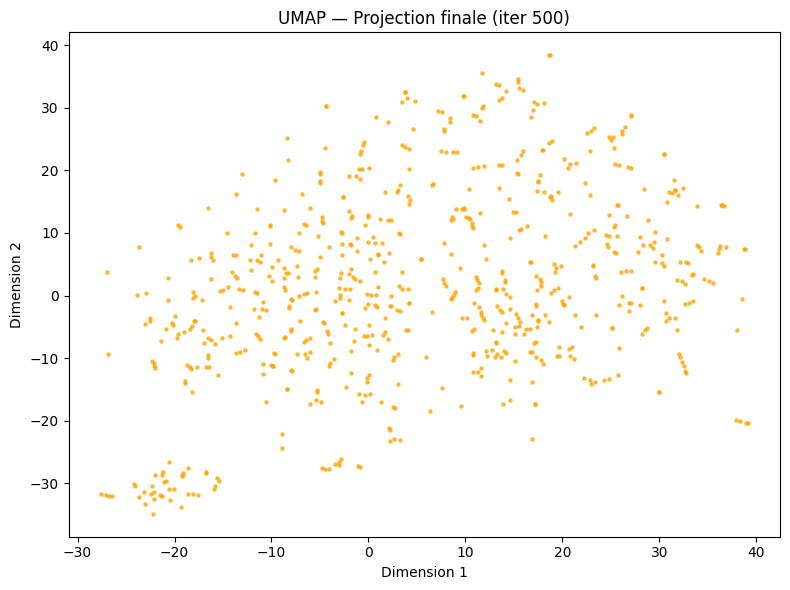

In [19]:
N_LOW_DIMS = 2
LEARNING_RATE_UMAP = 1.0
MAX_ITER_UMAP = 500

np.random.seed(12345)

# Spectral initialisation (like umap-learn default)
se = SpectralEmbedding(n_components=N_LOW_DIMS, affinity='precomputed', random_state=42)
Y_umap = se.fit_transform(P_umap)
# Rescale to [0, 10] x [0, 10] (umap-learn default output range)
for dim in range(N_LOW_DIMS):
    Y_umap[:, dim] = 10 * (Y_umap[:, dim] - Y_umap[:, dim].min()) / \
                    (Y_umap[:, dim].max() - Y_umap[:, dim].min() + 1e-10)

velocity_umap = np.zeros_like(Y_umap)
MOMENTUM_UMAP = 0.5

for t in range(MAX_ITER_UMAP):
    # Learning rate schedule (linear decay like umap-learn)
    lr = LEARNING_RATE_UMAP * (1 - t / MAX_ITER_UMAP)
    grad = CE_gradient_umap(P_umap, Y_umap, a_umap, b_umap)
    # Clip gradient for stability
    grad = np.clip(grad, -4, 4)
    velocity_umap = MOMENTUM_UMAP * velocity_umap - lr * grad
    Y_umap = Y_umap + velocity_umap
    if (t + 1) % 100 == 0:
        print(f"Iteration {t+1}/{MAX_ITER_UMAP}, CE = {CE_umap(P_umap, Y_umap, a_umap, b_umap):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(Y_umap[:, 0], Y_umap[:, 1], s=5, c='orange', alpha=0.7)
plt.title('UMAP — Projection finale (iter 500)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


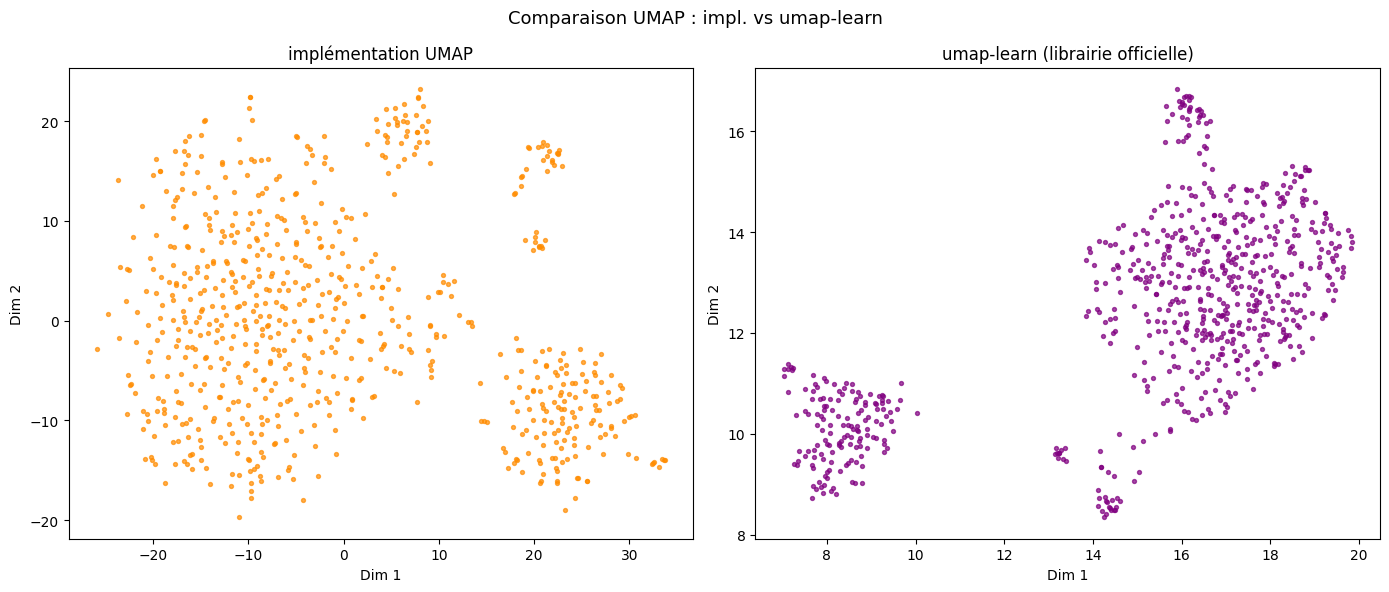

In [21]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=N_NEIGHBOR,    # = 15
    min_dist=MIN_DIST,         # = 0.25
    random_state=12345,
    init='spectral'            # même initialisation
)
Y_umap_lib = reducer.fit_transform(X)

# Comparaison côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.7, c='darkorange')
axes[0].set_title('implémentation UMAP')
axes[0].set_xlabel('Dim 1')
axes[0].set_ylabel('Dim 2')

axes[1].scatter(Y_umap_lib[:, 0], Y_umap_lib[:, 1], s=8, alpha=0.7, c='purple')
axes[1].set_title('umap-learn (librairie officielle)')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')

plt.suptitle('Comparaison UMAP : impl. vs umap-learn', fontsize=13)
plt.tight_layout()
plt.show()